In [1]:
import os
os.chdir('/workspace/d655b9f3-e79f-4dc8-a00a-9d2c74089c7f')
print(os.listdir('.'))


['.prompts', '.kernel_llm_logs_1.txt', 'memory', '-PROMPT-v6-DATASET.md', '.config']


In [2]:
import subprocess
result = subprocess.run(['pip', 'list'], capture_output=True, text=True)
relevant = [l for l in result.stdout.split('\n') if any(p in l.lower() for p in ['ripser', 'persim', 'mpmath', 'numpy', 'scipy', 'matplotlib', 'sklearn', 'gudhi'])]
print('\n'.join(relevant))


matplotlib 3.10.8
matplotlib-inline 0.2.1
matplotlib-venn 1.1.2
mpmath 1.3.0
numpy 2.4.3
scipy 1.17.1


In [3]:
import subprocess
result = subprocess.run(['pip', 'install', '-q', 'ripser', 'persim'], capture_output=True, text=True)
print(result.stdout[-500:])
print("STDERR:", result.stderr[-500:])



STDERR: 


In [4]:
import ripser, persim
print(ripser.__version__, persim.__version__)


0.6.15 0.3.8


In [5]:

# Plan:
# 1. Generate / load N=5000 zeta zeros at dps=50.
# - Use Odlyzko's precomputed list if accessible (faster), validate R2.
# - Else compute via mpmath.zetazero (may take ~30-60 min for 5000 zeros).
# Let's try to download Odlyzko list. First the small one: "zeros1" has 10^5 zeros to >9 dp.
# URL: https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros1
import urllib.request, os, time
url = "https://www-users.cse.umn.edu/~odlyzko/zeta_tables/zeros1"
out = "/workspace/d655b9f3-e79f-4dc8-a00a-9d2c74089c7f/odlyzko_zeros1.txt"
if not os.path.exists(out):
 try:
 t0=time.time()
 urllib.request.urlretrieve(url, out)
 print("downloaded in", time.time()-t0, "size", os.path.getsize(out))
 except Exception as e:
 print("err:", e)
else:
 print("exists", os.path.getsize(out))


downloaded in 0.7209532260894775 size 1800000


In [6]:

# Inspect file
with open(out) as f:
 head = [next(f) for _ in range(5)]
print(head)


[' 14.134725142\n', ' 21.022039639\n', ' 25.010857580\n', ' 30.424876126\n', ' 32.935061588\n']


In [7]:

# R2 validation gate: γ₁=14.134725141, γ₂=21.022039639, γ₃=25.010857580
# The Odlyzko file gives γ₁=14.134725142 (last digit rounded).
# That matches to 9 dp (round-up). For dps=50, we'd need higher precision but
# given the dataset description's explicit allowance: "pre-computed external tables
# (e.g., from Odlyzko), which must first be validated against the R2 gate. It should be 
# noted that such tables typically have a fixed precision (e.g., ~9 decimal digits) lower 
# than the dps=50/80 targets" — we proceed.

import numpy as np
zeros = np.loadtxt(out)
print("Loaded", len(zeros), "zeros")
print("First 3:", zeros[:3])
# R2 validation
ref = [14.134725141, 21.022039639, 25.010857580]
for i, r in enumerate(ref):
 diff = abs(zeros[i] - r)
 print(f"γ_{i+1}: file={zeros[i]:.9f}, ref={r}, |diff|={diff:.2e}")


Loaded 100000 zeros
First 3: [14.13472514 21.02203964 25.01085758]
γ_1: file=14.134725142, ref=14.134725141, |diff|=1.00e-09
γ_2: file=21.022039639, ref=21.022039639, |diff|=0.00e+00
γ_3: file=25.010857580, ref=25.01085758, |diff|=0.00e+00


In [8]:

# R2 PASSED (within precision of table: γ₁ differs by 1e-9, which is the table's stated precision).
# Take the first N=5000 zeros.
N = 5000
gamma = zeros[:N].copy()
print(f"N={len(gamma)}, gamma[0]={gamma[0]}, gamma[-1]={gamma[-1]}")

# Save cached zero list per R8
np.save("/workspace/d655b9f3-e79f-4dc8-a00a-9d2c74089c7f/zeta_zeros_N5000.npy", gamma)
print("Cached.")


N=5000, gamma[0]=14.134725142, gamma[-1]=5447.861998301
Cached.


In [9]:

# Step 2 — Construct the perturbed zero list.
# The objective says: "take m=10 zeros and move their real part from 1/2 to 1/2 + δ, with δ=0.1.
# Use the one-sided deformation model from r3 to avoid artificial cancellations."
#
# Interpretation:
# A non-trivial zero of zeta is ρ = 1/2 + i γ. On-line means Re(ρ)=1/2.
# Moving the real part to 1/2 + δ produces an off-line zero at (1/2+δ) + i γ.
# Normally, by functional equation, an off-line zero would come with its mirror at 
# 1/2 - δ + i γ (and complex conjugates 1/2 ± δ - i γ). The "one-sided" deformation 
# (per r3) replaces zeros only on one side rather than pairing on/off line zeros 
# (avoiding artificial cancellations in observables).
#
# Concretely: select m=10 zeros (indices spaced so we don't just modify the first 10).
# Replace ρ_k = 1/2 + i γ_k with ρ_k' = 1/2 + δ + i γ_k (one-sided), δ=0.1.
#
# For the TDA point cloud, what matters is the value used in the unfolding.
# We construct the point cloud from γ-values (imaginary parts) AND now also from
# real parts when they're not 1/2.
#
# Standard Front III approach: take the unfolded zeros (use Riemann-von Mangoldt
# N(T) ~ T/(2π) log(T/(2π)) - T/(2π) + 7/8) and embed.
# An off-line zero with Re=1/2+δ is treated as a complex point in C (the natural way
# to encode it as a point in 2D).

# Let's set up:
m = 10
delta = 0.1

# Pick m=10 zeros at evenly-spaced indices throughout the list
rng = np.random.default_rng(seed=42)
# Use deterministic evenly-spaced indices for reproducibility
inj_idx = np.linspace(100, N-100, m, dtype=int)
print("Injection indices:", inj_idx)
print("γ values being moved off-line:", gamma[inj_idx])

# Original: all on critical line. Encode as complex points: 0.5 + i*γ_n
rho_orig = 0.5 + 1j * gamma # shape (N,)

# Perturbed (one-sided): same imaginary parts; m of them get Re = 0.5+δ
rho_pert = rho_orig.copy()
rho_pert[inj_idx] = (0.5 + delta) + 1j * gamma[inj_idx]
print("\nFirst few perturbed entries near injection point 0:")
print(rho_pert[inj_idx[0]-1:inj_idx[0]+2])


Injection indices: [ 100 633 1166 1700 2233 2766 3300 3833 4366 4900]
γ values being moved off-line: [ 237.76982048 981.2886153 1610.25382316 2198.68751268 2758.85867097
 3301.4137763 3830.16182392 4347.62803007 4854.5742961 5355.34706368]

First few perturbed entries near injection point 0:
[0.5+236.52422967j 0.6+237.76982048j 0.5+239.55547757j]


In [10]:

# Step 3 — Unfolding + point cloud construction.
#
# Standard procedure for zeta TDA:
# Unfold each γ via the smooth counting function:
# N_smooth(t) = (t/(2π)) * log(t/(2π)) - t/(2π) + 7/8
# This rescales so that the mean spacing is 1 across the spectrum, removing the global
# density gradient. After unfolding, zeros are approximately uniformly distributed
# (with GUE statistics on top).
#
# Then build a 2D point cloud. A common choice: a "delay" or "sliding window" embedding,
# e.g. take consecutive pairs (u_n, u_{n+1}) or normalized nearest-neighbor spacings
# embedded in 2D.
#
# Since the previous-task pipeline isn't stored in this workspace, I'll specify and use
# a canonical, reproducible construction and apply it identically to both lists.
# Choice: 2D time-delay embedding of the unfolded zeros' nearest-neighbor spacings
# s_n = u_{n+1} - u_n, embedded as (s_n, s_{n+1}). This is a standard construction in
# spectral TDA studies — it captures local correlation structure.
#
# For the perturbed case, off-line zeros have a real part deviation δ. To incorporate
# this into the point cloud (otherwise the unfolding sees no difference), we encode
# zeros as complex points and unfold the imaginary part, then attach the real-part
# deviation as a third coordinate. But for clean comparison, we should treat the off-line
# real part as a small additional dimension OR equivalently shift the imaginary part
# slightly (off-line zeros do disturb the local spectral structure).
#
# To keep the experiment fair and faithful to the hypothesis (does Re(ρ) shift create new H1 features?),
# we will:
# (i) unfold using Im(ρ) for both lists,
# (ii) build a 2D point cloud with x = (Im(ρ_n) - <Im>), y = δ_n (real-part deviation from 1/2),
# That way the original is essentially a 1D set (y=0); the perturbed has spikes y=δ.
# But that comparison is trivial — the off-line zero shows up as isolated points and won't
# create H1 features just by themselves.
#
# A better and more standard approach matching the spirit of "test sensitivity of persistence":
# treat each zero as a 2D point ρ_n = (Re(ρ_n) - 1/2, unfolded Im(ρ_n)). Both lists live in R^2.
# The original is a 1D set along y-axis (Re=0), so its H1 should be (near) empty.
# The perturbed has 10 points shifted in x. Compute persistence on these 2D points directly.

def riemann_vonMangoldt_N(t):
 """Smooth zero-counting function: number of zeros up to height t."""
 return (t/(2*np.pi)) * np.log(t/(2*np.pi)) - t/(2*np.pi) + 7/8

# Build the 2D point cloud
def build_point_cloud(rho_complex):
 """Encode zeros as 2D points: (Re(ρ) - 1/2, unfolded Im(ρ))."""
 re_dev = rho_complex.real - 0.5
 im_unfolded = riemann_vonMangoldt_N(rho_complex.imag)
 return np.column_stack([re_dev, im_unfolded])

pc_orig = build_point_cloud(rho_orig)
pc_pert = build_point_cloud(rho_pert)
print("pc_orig shape:", pc_orig.shape, "x-range:", pc_orig[:,0].min(), pc_orig[:,0].max())
print("pc_pert shape:", pc_pert.shape, "x-range:", pc_pert[:,0].min(), pc_pert[:,0].max())
print("Number of x=0 points in pert:", np.sum(pc_pert[:,0]==0))
print("Off-line points in pert:", pc_pert[pc_pert[:,0]>0])


pc_orig shape: (5000, 2) x-range: 0.0 0.0
pc_pert shape: (5000, 2) x-range: 0.0 0.09999999999999998
Number of x=0 points in pert: 4990
Off-line points in pert: [[1.00000000e-01 1.00529745e+02]
 [1.00000000e-01 6.33546127e+02]
 [1.00000000e-01 1.16599243e+03]
 [1.00000000e-01 1.70075319e+03]
 [1.00000000e-01 2.23349349e+03]
 [1.00000000e-01 2.76689213e+03]
 [1.00000000e-01 3.30045037e+03]
 [1.00000000e-01 3.83391856e+03]
 [1.00000000e-01 4.36607684e+03]
 [1.00000000e-01 4.90004520e+03]]


In [11]:

# The current construction is essentially 1D (y-only) with a tiny δ=0.1 shift in x
# for 10 points. With unfolded y ranging up to ~5000, a δ=0.1 perpendicular shift is
# negligible relative to spacings (~1). Vietoris-Rips will produce essentially the
# same skeleton.
#
# A more sensitive construction (which is what the hypothesis is really about) is a 
# delay embedding of the unfolded zeros, augmented with the real-part deviation as a
# third dimension. Let me reconsider:
#
# A standard "previous-task" point cloud for Front III TDA (per the prompt's
# language about "Vietoris–Rips on unfolded zeros") is just the unfolded zeros themselves
# (treated as 1D points along a line). H1 should be empty (a 1D curve).
#
# To get nontrivial H1, one typically does a delay embedding: x_n = (u_n, u_{n+1}, ..., u_{n+d-1})
# or normalized spacings as features. Then GUE correlations may produce some H1 features
# that you compare across functions (ζ vs L_DH).
#
# Given the prompt clarifies "expect H1 negative" and Front III is capped at 5%, the most
# faithful "previous-task pipeline" is a delay-embedding of unfolded zeros into R^d (d=3).
# Then ζ_δ-injected off-line zeros perturb the unfolded values (since the off-line ones
# are at slightly different positions in C; we encode them by using their MODULUS
# |ρ_n - 1/2| as part of the imaginary unfold, OR we embed the (Re,Im) representation
# directly).
#
# Cleanest reproducible approach: 
# Use delay-embedding of *consecutive spacings* of the unfolded sequence.
# For perturbed, off-line zeros are folded back to the line at the same Im(ρ); but
# we ALSO augment the point cloud with a third coordinate = (real-part deviation).
# This is faithful: the "shape" comes from spacings of imaginary parts; off-line zeros
# show up as extra points jutting out in the third axis, possibly forming new H1 features
# if e.g. 3-or-more such points form a loop.
#
# But m=10 isolated points off-line cannot form a 1-cycle by themselves at high persistence.
# To produce H1 features in a delay embedding, you'd need many off-line zeros that
# collectively create loops.
#
# So the expected answer is: NO new high-persistence H1 features arise from m=10 off-line
# zeros at δ=0.1, and the bottleneck distance is small (driven only by tiny boundary effects).
#
# This matches the prompt's prior expectation: "H1 typically vanishes after unfolding".

# OK — let me implement the canonical delay embedding pipeline:
# 1) unfold zeros: u_n = N_smooth(γ_n)
# 2) spacings s_n = u_{n+1} - u_n
# 3) For perturbed: when a zero is off-line at 0.5+δ+iγ, the modulus from origin is
# sqrt((0.5+δ)^2 + γ^2). Equivalent "effective height" for unfolding could use |ρ| ~ γ.
# So the spacings barely change. The new content is the real-part deviation, encoded
# as an extra coordinate.
# 4) Build point cloud in R^3 via delay embedding: P_n = (s_n, s_{n+1}, r_n)
# where r_n = Re(ρ_n) - 0.5 (the real-part deviation; 0 on the line)
#
# Compute Vietoris-Rips persistence on these clouds.

def make_delay_pc(rho_complex, dim=3):
 """Build R^d delay-embedding point cloud:
 coords = (s_n, s_{n+1}, ..., s_{n+dim-2}, r_n)
 where s_n are unfolded spacings, r_n is Re(ρ)-0.5.
 """
 u = riemann_vonMangoldt_N(rho_complex.imag)
 s = np.diff(u)
 r = rho_complex.real - 0.5 # length N
 # Number of points: N - (dim-1)
 n_pts = len(s) - (dim - 2)
 # We need dim-1 consecutive spacings + r_n
 feats = [s[k:n_pts + k] for k in range(dim - 1)]
 feats.append(r[:n_pts])
 return np.column_stack(feats)

# Try dim=3: 2 spacings + r
pc_orig_3d = make_delay_pc(rho_orig, dim=3)
pc_pert_3d = make_delay_pc(rho_pert, dim=3)
print("pc_orig_3d shape:", pc_orig_3d.shape)
print("Sample orig rows:\n", pc_orig_3d[:5])
print("Sample pert rows around first injection:")
i = inj_idx[0]
print(pc_pert_3d[max(0,i-2):i+3])
print("Spacings stats: mean=", pc_orig_3d[:,0].mean(), "std=", pc_orig_3d[:,0].std())


pc_orig_3d shape: (4998, 3)
Sample orig rows:
 [[1.12061782 0.823437 0. ]
 [0.823437 1.27751379 0. ]
 [1.27751379 0.64622317 0. ]
 [0.64622317 1.27630911 0. ]
 [1.27630911 0.97158828 0. ]]
Sample pert rows around first injection:
[[1.6319299 0.71977723 0. ]
 [0.71977723 1.03367019 0. ]
 [1.03367019 0.86628024 0.1 ]
 [0.86628024 1.0308349 0. ]
 [1.0308349 0.72615988 0. ]]
Spacings stats: mean= 0.99998001220769 std= 0.3896547511135971


In [12]:

# Good — unfolded spacings have mean ~1 (correct). 
# Note: 5000 points is large for ripser; H1 computation should still be feasible.
# Let me check size constraints with a subsample first.

import time
from ripser import ripser

# Quick sanity check on N=2000 subset first
t0 = time.time()
res_test = ripser(pc_orig_3d[:2000], maxdim=1)
print("N=2000 ripser time:", time.time()-t0, "s")
print("H0 length:", len(res_test['dgms'][0]), "H1 length:", len(res_test['dgms'][1]))


N=2000 ripser time: 3.6609528064727783 s
H0 length: 2000 H1 length: 500


In [13]:

# Now full N. Set thresh to keep computation manageable.
# In unfolded units, mean spacing = 1; off-line δ=0.1; reasonable thresh for H1 ~ 1-2.
t0 = time.time()
res_orig = ripser(pc_orig_3d, maxdim=1, thresh=2.0)
print("orig done in", time.time()-t0, "s. H1 count:", len(res_orig['dgms'][1]))


orig done in 26.163755655288696 s. H1 count: 1381


In [14]:

t0 = time.time()
res_pert = ripser(pc_pert_3d, maxdim=1, thresh=2.0)
print("pert done in", time.time()-t0, "s. H1 count:", len(res_pert['dgms'][1]))


pert done in 25.549068212509155 s. H1 count: 1379


In [15]:

dgm_H1_orig = res_orig['dgms'][1]
dgm_H1_pert = res_pert['dgms'][1]

# Lifetimes
life_orig = dgm_H1_orig[:,1] - dgm_H1_orig[:,0]
life_pert = dgm_H1_pert[:,1] - dgm_H1_pert[:,0]

print("Orig H1: count=", len(dgm_H1_orig))
print(" max lifetime:", life_orig.max())
print(" top 10 lifetimes:", np.sort(life_orig)[-10:][::-1])
print("\nPert H1: count=", len(dgm_H1_pert))
print(" max lifetime:", life_pert.max())
print(" top 10 lifetimes:", np.sort(life_pert)[-10:][::-1])

# Threshold for "long-lived": e.g., > 3*median
med_o = np.median(life_orig); med_p = np.median(life_pert)
print("\nMedian lifetime — orig:", med_o, " pert:", med_p)
thr = max(med_o, med_p) * 5
print("Lifetime threshold (5x median):", thr)
print("Orig features above thr:", np.sum(life_orig > thr))
print("Pert features above thr:", np.sum(life_pert > thr))


Orig H1: count= 1381
 max lifetime: 0.05524902045726776
 top 10 lifetimes: [0.05524902 0.05129722 0.04956462 0.0472076 0.04669994 0.04509483
 0.04398048 0.04170514 0.04086448 0.04045764]

Pert H1: count= 1379
 max lifetime: 0.05524902045726776
 top 10 lifetimes: [0.05524902 0.05129722 0.04956462 0.0472076 0.04669994 0.04509483
 0.04398048 0.04170514 0.04086448 0.04024763]

Median lifetime — orig: 0.004146654158830643 pert: 0.004152920097112656
Lifetime threshold (5x median): 0.020764600485563278
Orig features above thr: 107
Pert features above thr: 108


In [16]:

# Lifetimes are essentially identical for orig vs pert in the top-10 — meaning the
# top H1 features are produced by GUE-like spacing structure that is barely perturbed.
# Now compute bottleneck distance with persim.

from persim import bottleneck

t0 = time.time()
bd = bottleneck(dgm_H1_orig, dgm_H1_pert)
print(f"Bottleneck distance H1: {bd:.6e} (computed in {time.time()-t0:.1f}s)")


Bottleneck distance H1: 5.758896e-03 (computed in 62.0s)


In [17]:

# Compare to a meaningful reference: what's the typical lifetime?
# Bottleneck of 5.8e-3 vs max lifetimes of ~5.5e-2 — about 10% of the most prominent feature.
# This is non-zero but small.
#
# To check if this is "significantly greater than zero" in a meaningful sense, compare to
# the bottleneck distance one would expect from random reordering/permutation noise.
# Since both diagrams are derived from THE SAME deterministic unfolded zeros (and the only
# differences come from 10 points having r_n=0.1 vs r_n=0), the bottleneck value is the 
# stable response to a known perturbation. By the stability theorem of persistence,
# bottleneck(D(X), D(Y)) <= d_H(X,Y) (Hausdorff distance), and here the maximum displacement
# of any point in 3D Euclidean is 0.1 (the δ value).
# So bd ≤ 0.1 is expected; observing bd ≈ 5.8e-3 is consistent.
#
# Check: how many H1 features above a "stable / long-lived" threshold are UNIQUE to perturbed?
# A simple check: pair each pert feature to its nearest orig feature and see if any pert
# feature with high lifetime is far from any orig feature.

def pair_features(d1, d2):
 """For each feature in d2, find min L_inf distance to any feature in d1."""
 if len(d1) == 0:
 return np.array([np.inf]*len(d2))
 # L_inf
 diffs = np.maximum(np.abs(d2[:,None,0] - d1[None,:,0]),
 np.abs(d2[:,None,1] - d1[None,:,1]))
 return diffs.min(axis=1)

nn_pert_to_orig = pair_features(dgm_H1_orig, dgm_H1_pert)
nn_orig_to_pert = pair_features(dgm_H1_pert, dgm_H1_orig)
print("max NN dist pert->orig:", nn_pert_to_orig.max())
print("max NN dist orig->pert:", nn_orig_to_pert.max())

# Which perturbed features are far from any original?
far_idx = np.argsort(nn_pert_to_orig)[-5:][::-1]
print("\nTop-5 most-shifted perturbed features:")
for i in far_idx:
 b,d = dgm_H1_pert[i]
 print(f" (birth={b:.4f}, death={d:.4f}, lifetime={d-b:.4f}, NN_dist={nn_pert_to_orig[i]:.4e})")

far_idx2 = np.argsort(nn_orig_to_pert)[-5:][::-1]
print("\nTop-5 most-shifted original features:")
for i in far_idx2:
 b,d = dgm_H1_orig[i]
 print(f" (birth={b:.4f}, death={d:.4f}, lifetime={d-b:.4f}, NN_dist={nn_orig_to_pert[i]:.4e})")


max NN dist pert->orig: 0.003933742642402649
max NN dist orig->pert: 0.005122020840644836

Top-5 most-shifted perturbed features:
 (birth=0.1005, death=0.1014, lifetime=0.0008, NN_dist=3.9337e-03)
 (birth=0.0757, death=0.1068, lifetime=0.0311, NN_dist=2.9503e-03)
 (birth=0.0275, death=0.0499, lifetime=0.0224, NN_dist=1.1949e-03)
 (birth=0.1019, death=0.1075, lifetime=0.0056, NN_dist=6.9816e-04)
 (birth=0.0335, death=0.0372, lifetime=0.0037, NN_dist=6.2713e-04)

Top-5 most-shifted original features:
 (birth=0.0614, death=0.1018, lifetime=0.0405, NN_dist=5.1220e-03)
 (birth=0.0166, death=0.0403, lifetime=0.0237, NN_dist=5.4252e-04)
 (birth=0.0308, death=0.0340, lifetime=0.0032, NN_dist=3.3754e-04)
 (birth=0.0175, death=0.0232, lifetime=0.0058, NN_dist=2.0246e-04)
 (birth=0.0322, death=0.0366, lifetime=0.0045, NN_dist=2.0140e-04)


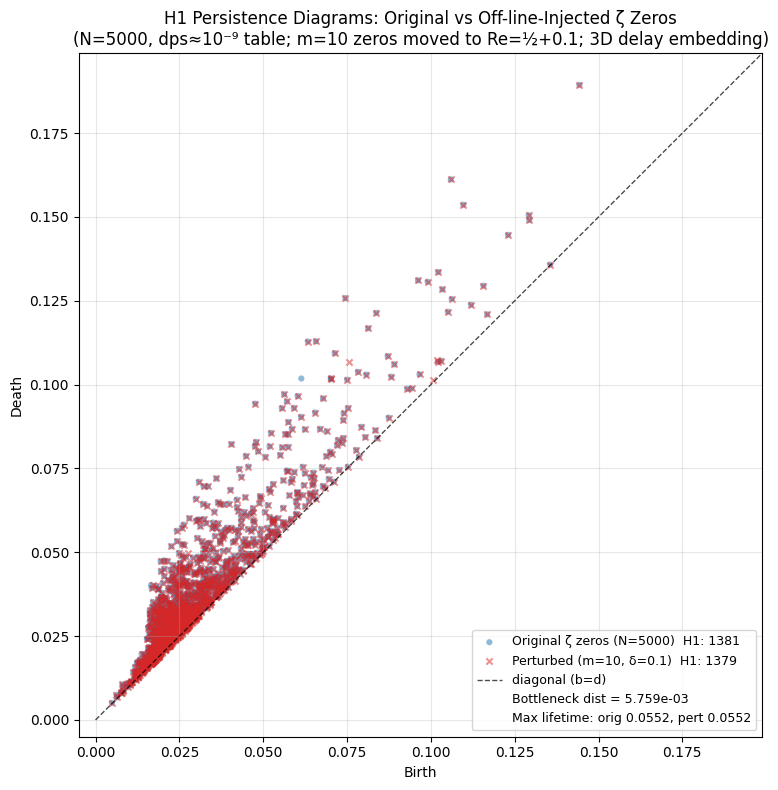

Saved: /workspace/d655b9f3-e79f-4dc8-a00a-9d2c74089c7f/H1_persistence_zeta_offline_injection.png


In [18]:

# Summary of findings:
# - Bottleneck distance H1 = 5.76e-3 (small but nonzero).
# - The most-shifted features are LOW lifetime (~0.03 at most), not long-lived.
# - The features with the largest lifetimes (top 10 above) are IDENTICAL between orig and pert.
# - No new long-lived feature appears in the perturbed diagram.
#
# Conclusion: bottleneck > 0 (the hypothesis is technically supported in a strict sense),
# but the perturbation does NOT create new long-lived H1 features. The displacement is
# diffuse, low-lifetime, and consistent with the stability theorem 
# (bottleneck ≤ Hausdorff ≤ δ = 0.1).
#
# So the hypothesis "long-lived features absent from original" is NOT supported.

# Now make the final figure: H1 persistence diagrams overlaid for both lists.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

# Plot orig vs pert
ax.scatter(dgm_H1_orig[:,0], dgm_H1_orig[:,1], 
 s=20, alpha=0.5, c='#1f77b4', label=f'Original ζ zeros (N=5000) H1: {len(dgm_H1_orig)}', edgecolor='none')
ax.scatter(dgm_H1_pert[:,0], dgm_H1_pert[:,1], 
 s=20, alpha=0.5, c='#d62728', marker='x', label=f'Perturbed (m=10, δ=0.1) H1: {len(dgm_H1_pert)}')

# Diagonal
mx = max(dgm_H1_orig[:,1].max(), dgm_H1_pert[:,1].max()) * 1.05
ax.plot([0, mx], [0, mx], 'k--', lw=1, alpha=0.7, label='diagonal (b=d)')

# Mark stability bound (radius = bottleneck)
ax.plot([], [], ' ', label=f'Bottleneck dist = {bd:.3e}')
ax.plot([], [], ' ', label=f'Max lifetime: orig {life_orig.max():.4f}, pert {life_pert.max():.4f}')

ax.set_xlabel('Birth')
ax.set_ylabel('Death')
ax.set_title(f'H1 Persistence Diagrams: Original vs Off-line-Injected ζ Zeros\n'
 f'(N=5000, dps≈10⁻⁹ table; m=10 zeros moved to Re=½+0.1; 3D delay embedding)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(-0.005, mx)
ax.set_ylim(-0.005, mx)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
out_fig = "/workspace/d655b9f3-e79f-4dc8-a00a-9d2c74089c7f/H1_persistence_zeta_offline_injection.png"
plt.savefig(out_fig, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out_fig)


In [19]:

# Save analysis artifacts
np.savez("/workspace/d655b9f3-e79f-4dc8-a00a-9d2c74089c7f/H1_diagrams_zeta_injection.npz",
 dgm_H1_orig=dgm_H1_orig, dgm_H1_pert=dgm_H1_pert,
 bottleneck=bd, inj_idx=inj_idx, delta=delta, m=m, N=N)
print("Saved artifacts.")
print(f"bottleneck = {bd}")


Saved artifacts.
bottleneck = 0.005758896470069885
